In [1]:
!pip list

Package                           Version
--------------------------------- ------------------
adagio                            0.2.6
aext-assistant                    4.20.0
aext-assistant-server             4.20.0
aext-core                         4.20.0
aext-core-server                  4.20.0
aext_environments_server          4.20.0
aext-panels                       4.20.0
aext-panels-server                4.20.0
aext-project-filebrowser-server   4.20.0
aext-share-notebook               4.20.0
aext-share-notebook-server        4.20.0
aext-shared                       4.20.0
aext-toolbox                      4.20.0
affine                            2.4.0
aiobotocore                       2.12.3
aiohappyeyeballs                  2.4.0
aiohttp                           3.10.5
aioitertools                      0.7.1
aiosignal                         1.2.0
alabaster                         0.7.16
alembic                           1.13.3
altair                            5.0.1
anaconda-

In [2]:
!pip install pyAgrum

import pyAgrum as gum                                              # cargar red
import pyAgrum.lib.notebook as gnb                       # para graficar la red

# https://pyagrum.readthedocs.io/
# https://agrum.gitlab.io/         Para instalar la librería: pip install pyAgrum


ModuleNotFoundError: No module named 'pyAgrum'

In [ ]:
red = gum.BayesNet('Alumno')                                      # creamos red
print(red)

BN{nodes: 0, arcs: 0, domainSize: 1, dim: 0, mem: 0o}


In [ ]:
# primera variable

# Creamos una variable categórica (discreta) llamada 'ex'
# - 'ex' → nombre corto interno en la red
# - 'examen' → nombre descriptivo
# - 2 → cantidad de estados posibles (por defecto se llamarán 0 y 1)
ex = red.add(gum.LabelizedVariable('ex', 'examen', 2))  

# Al agregar la variable a la red, se devuelve su índice interno (ej. 0 si es la primera).
print(ex)


0


In [ ]:
#    las demás variables
enf = red.add(gum.LabelizedVariable('enf', 'enfermo', 2))   #agregamos la 2° var
print(enf)
au = red.add(gum.LabelizedVariable('au', 'ausente', 2))    #agregamos la 3ra var
print(au)

1
2


In [ ]:
#   veamos la red
print(red)

BN{nodes: 3, arcs: 0, domainSize: 8, dim: 3, mem: 48o}


In [ ]:
#   arcos

# Creamos una relación (arco dirigido) de 'ex' → 'enf'
# Significa que el estado del examen puede influir en si el alumno está enfermo.
red.addArc(ex, enf)                                      

# Creamos una relación (arco dirigido) de 'ex' → 'au'
# Significa que el examen puede influir en si el alumno está ausente.
red.addArc(ex, au)

# Creamos una relación (arco dirigido) de 'enf' → 'au'
# Significa que el hecho de estar enfermo puede influir en que el alumno falte.
red.addArc(enf, au)

In [ ]:
# veamos la red otra vez

print(red)


BN{nodes: 3, arcs: 3, domainSize: 8, dim: 7, mem: 112o}


In [ ]:
# la graficamos

red

(pyAgrum.BayesNet<double>@0x5948d8b0a060) BN{nodes: 3, arcs: 3, domainSize: 8, dim: 7, mem: 112o}

In [ ]:
# hay una manera más rápida de crear la red
bn=gum.fastBN("ex->enf->au<-ex")
bn

(pyAgrum.BayesNet<double>@0x5948d863ac20) BN{nodes: 3, arcs: 3, domainSize: 8, dim: 7, mem: 112o}

In [ ]:
print(bn)

BN{nodes: 3, arcs: 3, domainSize: 8, dim: 7, mem: 112o}


In [ ]:
#%%  ahora a cargar las tablas de probabilidades condicionales o CPT
# hay varias maneras de hacerlo

# Definimos la distribución de probabilidad para la variable 'ex' (examen)
# La variable 'ex' tiene 2 estados: 0 y 1
# fillWith([0.7, 0.3]) significa:
#   P(ex=0) = 0.7   (ejemplo: probabilidad de "no examen")
#   P(ex=1) = 0.3   (ejemplo: probabilidad de "sí examen")
red.cpt(ex).fillWith([0.7, 0.3])   


(pyAgrum.Potential<double>@0x5948d93dc070) 
  ex               |
0        |1        |
---------|---------|
 0.7000  | 0.3000  |

In [ ]:
# otra manera es con un diccionario
red.cpt('enf')[{'ex':0}] = [0.43, 0.57]   # ex=0, enf=0 ó enf=1
red.cpt('enf')[{'ex':1}] = [0.33, 0.67]   # ex=1, enf=0 ó enf=1
red.cpt('au')[{'ex':0, 'enf':0}] = [0,1]
red.cpt('au')[{'ex':0, 'enf':1}] = [0.5,0.5]
red.cpt('au')[{'ex':1, 'enf':0}] = [1,0]
red.cpt('au')[{'ex':1, 'enf':1}] = [0.5,0.5]

In [ ]:
red.cpt('enf')

(pyAgrum.Potential<double>@0x5948d870d960) 
      ||  enf              |
ex    ||0        |1        |
------||---------|---------|
0     || 0.4300  | 0.5700  |
1     || 0.3300  | 0.6700  |

In [ ]:
red.cpt('au')

(pyAgrum.Potential<double>@0x5948d8be8580) 
             ||  au               |
ex    |enf   ||0        |1        |
------|------||---------|---------|
0     |0     || 0.0000  | 1.0000  |
1     |0     || 1.0000  | 0.0000  |
0     |1     || 0.5000  | 0.5000  |
1     |1     || 0.5000  | 0.5000  |

In [ ]:
red.cpt('ex')

(pyAgrum.Potential<double>@0x5948d93dc070) 
  ex               |
0        |1        |
---------|---------|
 0.7000  | 0.3000  |

In [ ]:
# ya está completa la red
# también se puede guardar para después recargarla --> persistencia

print(gum.availableBNExts())

bif|dsl|net|bifxml|o3prm|uai|xdsl|pkl


In [ ]:
gum.saveBN(red,"alumno.net")

In [ ]:
red2=gum.loadBN('alumno.net')
red2

(pyAgrum.BayesNet<double>@0x5948da58e850) BN{nodes: 3, arcs: 3, domainSize: 8, dim: 7, mem: 112o}

In [ ]:
!ls

alumno.net  sample_data


In [ ]:
# hacemos propagar la información de las probabilidades por la red 
# -> preparar el cálculo de probabilidades posteriores

# 'LazyPropagation' es un algoritmo de inferencia exacta en redes bayesianas
# que permite calcular distribuciones posteriores dado evidencia.
# Se inicializa pasando como parámetro la red que construimos ('red').
ie = gum.LazyPropagation(red)


In [ ]:
# Ejecutamos la inferencia sobre la red ya definida
ie.makeInference()

# Obtenemos la distribución posterior de la variable 'au' (ausente)
# Esto devuelve un objeto con P(au=0) y P(au=1), calculadas según la red.
ie.posterior(au)

(pyAgrum.Potential<double>@0x5948da2a0860) 
  au               |
0        |1        |
---------|---------|
 0.3990  | 0.6010  |

In [ ]:
#  agregamos evidencia y preguntamos

# Fijamos la evidencia: 'ex'=1 (es decir, sí hubo examen)
ie.setEvidence({'ex':1})

# Recalculamos la inferencia teniendo en cuenta la evidencia
ie.makeInference()

# Consultamos la distribución posterior de la variable 'au' (ausente)
# Ahora devuelve P(au=0) y P(au=1) condicionadas a que ex=1.
ie.posterior(au)


(pyAgrum.Potential<double>@0x5948da4c43e0) 
  au               |
0        |1        |
---------|---------|
 0.6650  | 0.3350  |

In [ ]:
# agregamos evidencia y preguntamos desde otra variable (en un sentido y otro)

# Fijamos la evidencia: 'au'=0 (es decir, el alumno NO estuvo ausente)
ie.setEvidence({'au':0})

# Recalculamos la inferencia considerando esa nueva evidencia
ie.makeInference()

# Consultamos la distribución posterior de la variable 'ex' (examen)
# Esto devuelve P(ex=0 | au=0) y P(ex=1 | au=0)
# Es decir, la probabilidad de que haya habido (o no) examen
# sabiendo que el alumno NO faltó.
ie.posterior(ex)


(pyAgrum.Potential<double>@0x5948da8735b0) 
  ex               |
0        |1        |
---------|---------|
 0.5000  | 0.5000  |

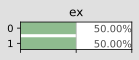

In [ ]:
gnb.showProba(ie.posterior("ex"))

In [ ]:
ie.setEvidence({'enf':0, 'ex':1})
ie.makeInference()
ie.posterior(au)

(pyAgrum.Potential<double>@0x5948da204f40) 
  au               |
0        |1        |
---------|---------|
 1.0000  | 0.0000  |

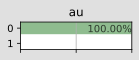

In [ ]:
# visualizamos de otra manera
gnb.showProba(ie.posterior("au"))